# SVD++

We first install the necessary packages.

In [1]:
pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

## Temporal Splitting on Newest Data

We split the data temporally. In other words, we first find the 100000 most recent ratings. We then reserve the newest 20000 of the 100000 ratings as the test set, while the remaining 80000 is used as the training set.

In [3]:
full = pd.read_csv('data.csv').drop(columns=['Unnamed: 0'])[-100000:] # data.csv contains the 1000000 newest ratings sorted by rating date from the oldest to the newest
full # full contains the 100000 newest ratings

,movie_id,user_id,rating,date,Year,Title
100000,13673,1699005,5,2005-12-30,1995,Toy Story
100001,16047,24892,4,2005-12-30,2005,Because of Winn-Dixie
100002,4159,814572,3,2005-12-30,2002,Barbershop
100003,8181,2073708,2,2005-12-30,1995,The Net
100004,4067,1672834,4,2005-12-30,1976,Silver Streak
...,...,...,...,...,...,...
199995,8993,2183787,4,2005-12-31,2005,Family Guy Presents: Stewie Griffin: The Untol...
199996,7430,258170,4,2005-12-31,2001,Six Feet Under: Season 1
199997,8467,1534359,5,2005-12-31,1996,Eraser
199998,10168,2543295,2,2005-12-31,2003,The League of Extraordinary Gentlemen


In [4]:
train = full[:80000] # the 80000 ratings used in training
train

,movie_id,user_id,rating,date,Year,Title
100000,13673,1699005,5,2005-12-30,1995,Toy Story
100001,16047,24892,4,2005-12-30,2005,Because of Winn-Dixie
100002,4159,814572,3,2005-12-30,2002,Barbershop
100003,8181,2073708,2,2005-12-30,1995,The Net
100004,4067,1672834,4,2005-12-30,1976,Silver Streak
...,...,...,...,...,...,...
179995,13629,1318034,4,2005-12-31,1951,Alice in Wonderland
179996,17324,1719503,4,2005-12-31,2005,Hitch
179997,17324,22846,5,2005-12-31,2005,Hitch
179998,3860,1799620,2,2005-12-31,2003,Bruce Almighty


In [5]:
test = full[-20000:] # the 20000 ratings used for testing
test

,movie_id,user_id,rating,date,Year,Title
180000,16445,1250138,2,2005-12-31,2003,"House of 1,000 Corpses"
180001,6850,714682,1,2005-12-31,2005,Lords of Dogtown
180002,3441,859907,2,2005-12-31,2005,Kicking & Screaming
180003,10748,2373473,3,2005-12-31,1987,Hamburger Hill
180004,5496,1678873,2,2005-12-31,2004,"I, Robot"
...,...,...,...,...,...,...
199995,8993,2183787,4,2005-12-31,2005,Family Guy Presents: Stewie Griffin: The Untol...
199996,7430,258170,4,2005-12-31,2001,Six Feet Under: Season 1
199997,8467,1534359,5,2005-12-31,1996,Eraser
199998,10168,2543295,2,2005-12-31,2003,The League of Extraordinary Gentlemen


In [6]:
len(train['movie_id'].unique()) # number of movies in training set

7648

In [7]:
len(train['user_id'].unique()) # number of users in training set

13245

#### Further Split of Train and Validation Sets

We use the validation set approach to select the hyperparameters for each of the models. In this case, we further divide the training set for the models into a non-validation set of size 64000 (used for training in the validation set approach) and a validation set of size 16000 (used for testing in the validation set approach).

In [8]:
non_validation = train[:64000]
non_validation # used for training when selecting hyperparameters

,movie_id,user_id,rating,date,Year,Title
100000,13673,1699005,5,2005-12-30,1995,Toy Story
100001,16047,24892,4,2005-12-30,2005,Because of Winn-Dixie
100002,4159,814572,3,2005-12-30,2002,Barbershop
100003,8181,2073708,2,2005-12-30,1995,The Net
100004,4067,1672834,4,2005-12-30,1976,Silver Streak
...,...,...,...,...,...,...
163995,5805,573429,3,2005-12-31,1998,Mr. Show: Season 4
163996,12966,372124,2,2005-12-31,2004,The Aviator
163997,9134,2249750,2,2005-12-31,2004,A Day Without a Mexican
163998,8312,923517,3,2005-12-31,1995,Jury Duty


In [9]:
validation = train[64000:]
validation # used for testing when selecting hyperparameters

,movie_id,user_id,rating,date,Year,Title
164000,8928,1655500,4,2005-12-31,2002,Snow Dogs
164001,3017,2448705,4,2005-12-31,1985,Cocoon
164002,3685,1885503,3,2005-12-31,2000,Scooby-Doo's Spookiest Tales
164003,6610,1971298,2,2005-12-31,1965,The Pawnbroker
164004,7625,2524708,3,2005-12-31,1977,Young Lady Chatterley
...,...,...,...,...,...,...
179995,13629,1318034,4,2005-12-31,1951,Alice in Wonderland
179996,17324,1719503,4,2005-12-31,2005,Hitch
179997,17324,22846,5,2005-12-31,2005,Hitch
179998,3860,1799620,2,2005-12-31,2003,Bruce Almighty


## compute_rmse Function

We define a compute_rmse function that takes in the predicted output and actual output, so that we can conveniently compute the RMSE of our predictions.

In [12]:
# Takes in two NumPy arrays
def compute_rmse(predicted, actual):
    return np.sqrt(np.mean((predicted - actual) * (predicted - actual)))

## Model Training and Testing

We take advantage of the SVD++ implementation in the surprise package. We first prepare the training and testing data into a form usable by surprise's SVD++.

In [13]:
from surprise import reader, Dataset, Trainset, SVDpp, accuracy
from surprise.model_selection import train_test_split
from surprise.dataset import DatasetAutoFolds
ratings_reader = reader.Reader(rating_scale=(1,5))
train_dset = Dataset.load_from_df(train[['user_id', 'movie_id', 'rating']], ratings_reader)
test_dset = Dataset.load_from_df(test[['user_id', 'movie_id', 'rating']], ratings_reader)
trainset = DatasetAutoFolds.build_full_trainset(train_dset)
testset = [tuple(x) for x in test[['user_id', 'movie_id', 'rating']].values]

We now select the hyperparameters using the validation set approach.

In [14]:
# Prepare training and validation data
train_dset_non_valid = Dataset.load_from_df(non_validation[['user_id', 'movie_id', 'rating']], ratings_reader)
test_dset_valid = Dataset.load_from_df(validation[['user_id', 'movie_id', 'rating']], ratings_reader)
trainset_non_valid = DatasetAutoFolds.build_full_trainset(train_dset_non_valid)
testset_valid = [tuple(x) for x in validation[['user_id', 'movie_id', 'rating']].values]

# Candidate hyperparameter values
n_factors_list = [10, 20, 100]
n_epochs_list = [10, 20, 100]
lr_all_list = [0.002, 0.02]
reg_all_list = [0.02, 0.2]

best_rmse = np.inf
best_params = None

# Main loop
for n_factors in n_factors_list:
  for n_epochs in n_epochs_list:
    for lr_all in lr_all_list:
      for reg_all in reg_all_list:
        model = SVDpp(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr_all, reg_all=reg_all)
        model.fit(trainset_non_valid)
        predictions = model.test(testset_valid)
        rmse = accuracy.rmse(predictions)
        print(n_factors, n_epochs, lr_all, reg_all)
        if (rmse < best_rmse):
          best_rmse = rmse
          best_params = [n_factors, n_epochs, lr_all, reg_all]

RMSE: 0.9799
10 10 0.002 0.02
RMSE: 0.9817
10 10 0.002 0.2
RMSE: 0.9368
10 10 0.02 0.02
RMSE: 0.9334
10 10 0.02 0.2
RMSE: 0.9566
10 20 0.002 0.02
RMSE: 0.9588
10 20 0.002 0.2
RMSE: 0.9571
10 20 0.02 0.02
RMSE: 0.9356
10 20 0.02 0.2
RMSE: 0.9376
10 100 0.002 0.02
RMSE: 0.9331
10 100 0.002 0.2
RMSE: 1.0485
10 100 0.02 0.02
RMSE: 0.9531
10 100 0.02 0.2
RMSE: 0.9805
20 10 0.002 0.02
RMSE: 0.9823
20 10 0.002 0.2
RMSE: 0.9371
20 10 0.02 0.02
RMSE: 0.9332
20 10 0.02 0.2
RMSE: 0.9570
20 20 0.002 0.02
RMSE: 0.9593
20 20 0.002 0.2
RMSE: 0.9586
20 20 0.02 0.02
RMSE: 0.9352
20 20 0.02 0.2
RMSE: 0.9402
20 100 0.002 0.02
RMSE: 0.9334
20 100 0.002 0.2
RMSE: 1.0082
20 100 0.02 0.02
RMSE: 0.9516
20 100 0.02 0.2
RMSE: 0.9839
100 10 0.002 0.02
RMSE: 0.9854
100 10 0.002 0.2
RMSE: 0.9432
100 10 0.02 0.02
RMSE: 0.9350
100 10 0.02 0.2
RMSE: 0.9619
100 20 0.002 0.02
RMSE: 0.9620
100 20 0.002 0.2
RMSE: 0.9517
100 20 0.02 0.02
RMSE: 0.9355
100 20 0.02 0.2
RMSE: 0.9483
100 100 0.002 0.02
RMSE: 0.9356
100 100 0.0

We selected n_factor=10, n_epochs=100, lr_all=0.002, and reg_all=0.2.

In [15]:
best_rmse, best_params

(np.float64(0.9330839051687088), [10, 100, 0.002, 0.2])

We now train the model and evaluate its test RMSE. The test RMSE yielded is around 0.9179.

In [16]:
from surprise.prediction_algorithms.matrix_factorization import SVDpp
from surprise import accuracy
svdpp = SVDpp(n_factors=10, n_epochs=100, lr_all=0.002, reg_all=0.2)
svdpp.fit(trainset)
predictions = svdpp.test(testset)
accuracy.rmse(predictions)

RMSE: 0.9179


np.float64(0.9179188438227041)

## Plots

Finally, we make plots of the test RMSE against varying hyperparameter values. We first define a svdpp_batch_rmse() function that evaluates the test RMSE of SVD++ at different hyperparameter values.

In [17]:
def svdpp_batch_rmse(trainset, testset, n_factors=[10], n_epochs=[10], lr_all =[0.02], reg_all=[0.2]):
    rmse_list = []
    for k in n_factors:
        for e in n_epochs:
          for r in reg_all:
            for l in lr_all:
              model = SVDpp(n_factors=k, n_epochs=e, lr_all=l, reg_all=r)
              model.fit(trainset)
              predictions = model.test(testset)
              rmse_list.append(accuracy.rmse(predictions))
    return np.array(rmse_list)

We now vary the hyperparameters and compute the test RMSE under these hyperparameter values.

In [18]:
rmse_list_n_factors = svdpp_batch_rmse(trainset, testset, n_factors=[10,20,50,100,1000]) # Try the n_factors values in the list
rmse_list_n_factors

RMSE: 0.9185
RMSE: 0.9184
RMSE: 0.9186
RMSE: 0.9192
RMSE: 0.9321


array([0.91845471, 0.91843583, 0.918615  , 0.91924733, 0.93205931])

In [19]:
rmse_list_n_epochs = svdpp_batch_rmse(trainset, testset, n_epochs=[10,20,50,100]) # Try the n_epochs values in the list
rmse_list_n_epochs

RMSE: 0.9186
RMSE: 0.9215
RMSE: 0.9281
RMSE: 0.9327


array([0.91860754, 0.9215164 , 0.92810606, 0.93265413])

In [20]:
rmse_list_lr_all = svdpp_batch_rmse(trainset, testset, lr_all=[0.007, 0.02, 0.07, 0.2]) # Try the lr_all values in the list
rmse_list_lr_all

RMSE: 0.9237
RMSE: 0.9185
RMSE: 0.9308
RMSE: 0.9726


array([0.9236733 , 0.91846045, 0.93081128, 0.97255445])

In [21]:
rmse_list_reg_all = svdpp_batch_rmse(trainset, testset, reg_all=[0.0002, 0.007, 0.02, 0.07, 0.2]) # Try the reg_all values in the list
rmse_list_reg_all

RMSE: 0.9400
RMSE: 0.9263
RMSE: 0.9213
RMSE: 0.9168
RMSE: 0.9185


array([0.93995582, 0.92631695, 0.9212864 , 0.91675639, 0.91847489])

We now plot the test RMSE against varying values of different hyperparameters.

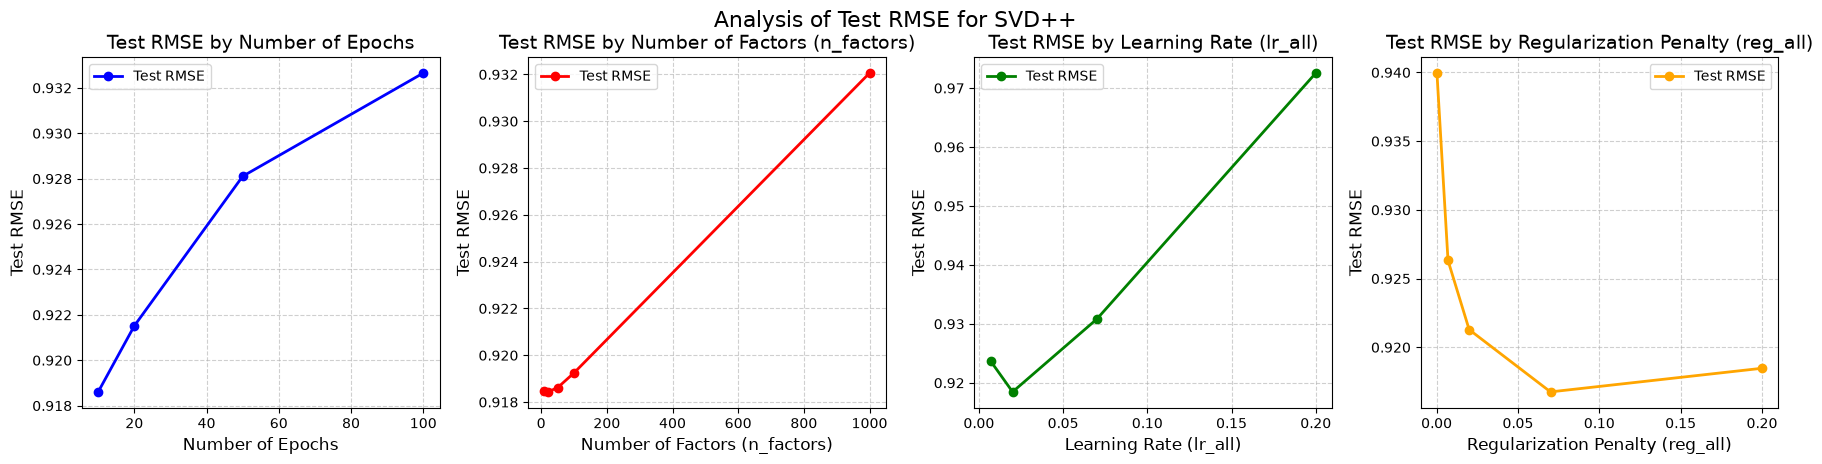

In [22]:
import matplotlib.pyplot as plt

# Create a grid of subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

x1 = [10, 20, 50, 100]

# First plot
axes[0].plot(x1, rmse_list_n_epochs, label='Test RMSE', color='blue', marker='o', linewidth=2)
axes[0].set_title('Test RMSE by Number of Epochs', fontsize=14)
axes[0].set_xlabel('Number of Epochs', fontsize=12)
axes[0].set_ylabel('Test RMSE', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

x2 = [10, 20, 50, 100, 1000]

# Second plot
axes[1].plot(x2, rmse_list_n_factors, label='Test RMSE', color='red', marker='o', linewidth=2)
axes[1].set_title('Test RMSE by Number of Factors (n_factors)', fontsize=14)
axes[1].set_xlabel('Number of Factors (n_factors)', fontsize=12)
axes[1].set_ylabel('Test RMSE', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

x3 = [0.007, 0.02, 0.07, 0.2]

# Third plot
axes[2].plot(x3, rmse_list_lr_all, label='Test RMSE', color='green', marker='o', linewidth=2)
axes[2].set_title('Test RMSE by Learning Rate (lr_all)', fontsize=14)
axes[2].set_xlabel('Learning Rate (lr_all)', fontsize=12)
axes[2].set_ylabel('Test RMSE', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(fontsize=10)

x4 = [0.0002, 0.007, 0.02, 0.07, 0.2]

# Fourth plot
axes[3].plot(x4, rmse_list_reg_all, label='Test RMSE', color='orange', marker='o', linewidth=2)
axes[3].set_title('Test RMSE by Regularization Penalty (reg_all)', fontsize=14)
axes[3].set_xlabel('Regularization Penalty (reg_all)', fontsize=12)
axes[3].set_ylabel('Test RMSE', fontsize=12)
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend(fontsize=10)

# Adjust layout
plt.tight_layout()

# Add a title for the entire figure
fig.suptitle('Analysis of Test RMSE for SVD++', fontsize=16, y=1.02)

plt.show()